# Reinforcement Learning

## Introduction

### Q-Learning

Q-Learning is a reinforcement learning algorithm where the agent learns by trial and error — it takes actions, gets rewards (or penalties), and slowly figures out which actions are worth taking in which states. The core idea is a Q-table, a 2D array of shape `(n_states, n_actions)`, where each cell holds an estimate of how good it is to take a given action in a given state.

After every step the agent updates the relevant cell using:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \cdot \left[\text{target} - Q(s, a)\right]
$$

The `target` is what we think the value *should* be, and it's computed differently depending on what happened:
- **terminated** — the episode ended for real (e.g. passenger delivered), so `target = r`. There's no next state, so we don't try to bootstrap from one.
- **truncated or regular step** — `target = r + γ · max_a' Q(s', a')`, we use the best known value of the next state to estimate the future.

Getting this distinction wrong is a common bug — if you treat a terminal state like a regular one, you add a discounted future reward that doesn't actually exist, which slowly corrupts the whole table.

For exploration the agent uses **ε-greedy**: most of the time it picks the best known action, but with probability ε it picks randomly. Epsilon starts high (lots of exploration) and decays after each episode, so over time the agent stops exploring and starts exploiting what it learned.

---

### SARSA

SARSA is an algorithm similiar to Q-Learning — it uses the same Q-table structure and the same ε-greedy exploration, but the update rule is slightly different. Instead of bootstrapping from the *best possible* next action, it bootstraps from the action the agent *actually chose* next:

$$
Q(s, a) \leftarrow Q(s, a) + \alpha \cdot \left[r + \gamma \cdot Q(s', a') - Q(s, a)\right]
$$

where `a'` is the action selected by the ε-greedy policy in state `s'`, not the greedy maximum. The name SARSA comes from the tuple it uses: **S**tate, **A**ction, **R**eward, **S**tate, **A**ction.

The practical difference: Q-Learning is *off-policy* — it learns the value of the optimal policy regardless of how it explores. SARSA is *on-policy* — it learns the value of the policy it's actually following, epsilon included. This makes SARSA more conservative in risky environments (it "knows" it might take a random step) while Q-Learning tends to be more aggressive.

The terminated case works the same way as in Q-Learning: if the episode ended, `target = r` with no bootstrapping.

To switch between the two algorithms, pass `use_sarsa=True` when constructing an `Experiment` or `QLearningAgent`. The runner handles the rest — SARSA requires selecting `next_action` *before* calling `update()` so the same action is used for both the update and the next step, which `ExperimentRunner.run_episode` takes care of automatically.

---

### Classes

### `TrainingConfig`
Just a dataclass with all the hyperparameters in one place: `alpha`, `gamma`, `epsilon_start`, `epsilon_end`, `epsilon_decay`, `n_episodes`, `max_steps`. Passing this around instead of a bunch of loose floats keeps things clean.

### `QLearningAgent`
The actual algorithm lives here. Holds the `q_table` and implements:

- `select_action(state, explore)` — ε-greedy action selection; with `explore=False` it's pure greedy (used when evaluating)
- `update(...)` — the update rule with the terminated/truncated logic described above; when `use_sarsa=True`, expects a `next_action` argument and uses `Q(s', a')` instead of `max Q(s', ·)`
- `decay_epsilon()` — multiplies epsilon by the decay factor after each episode

### `ExperimentRunner`
Wraps the agent and the gym environment together. Handles the step loop so you don't have to write it everywhere.

- `run_episode(training)` — runs one episode; if `training=True` it calls `update()` and `decay_epsilon()` along the way; for SARSA, selects `next_action` before the update so the same action is committed to the Q-update and carried into the next step
- `train()` — loops over all episodes, returns a `TrainingResult` with stats and a copy of the final Q-table
- `run_random(n_episodes)` — same thing but with random actions, no learning; used as a baseline

### `Evaluator`
Computes statistics and draws plots. Nothing fancy, just numpy for the numbers and matplotlib for the charts.

- `stability_analysis(results)` — takes results from multiple training runs and computes mean/std/min/max across them
- `plot_learning_curve` — reward over episodes with a rolling mean to smooth out the noise
- `plot_comparison` — boxplot comparing Q-Learning (or SARSA) vs random agent
- `plot_stability` — shows how consistent training is across runs (mean ± std band)

### `Experiment`
The top-level class that ties everything together. You give it an `env_id` string and it handles the rest — trains the agent multiple times, picks the best run, evaluates it, and collects random baseline stats. Pass `use_sarsa=True` to switch the algorithm; everything else stays the same. The notebook only ever touches this class.

#### Result dataclasses
`EpisodeStats` — stores what happened in one episode.  
`TrainingResult` — stores the full training history plus the final Q-table.  
`BenchmarkResult` — aggregates stats across multiple runs for the stability analysis.

## Experiments

First of all, the necessary imports will be made as well as the other miscellanous methods will be called to prepare for the experiments

In [2]:
from modules.config import TrainingConfig
from modules.experiment import Experiment, grid_search
import pandas as pd

pd.set_option('display.max_rows', None)

### Q-Learning

As the first experiment, a single experiment will be run with arbitrary parameters

100%|██████████| 10/10 [01:23<00:00,  8.31s/it]


Algorithm: Q-Learning
Stability (10 runs):  mean=-12.24  std=0.18  min=-12.53  max=-11.91
Q-Learning eval:     7.91
Random agent:     -771.39


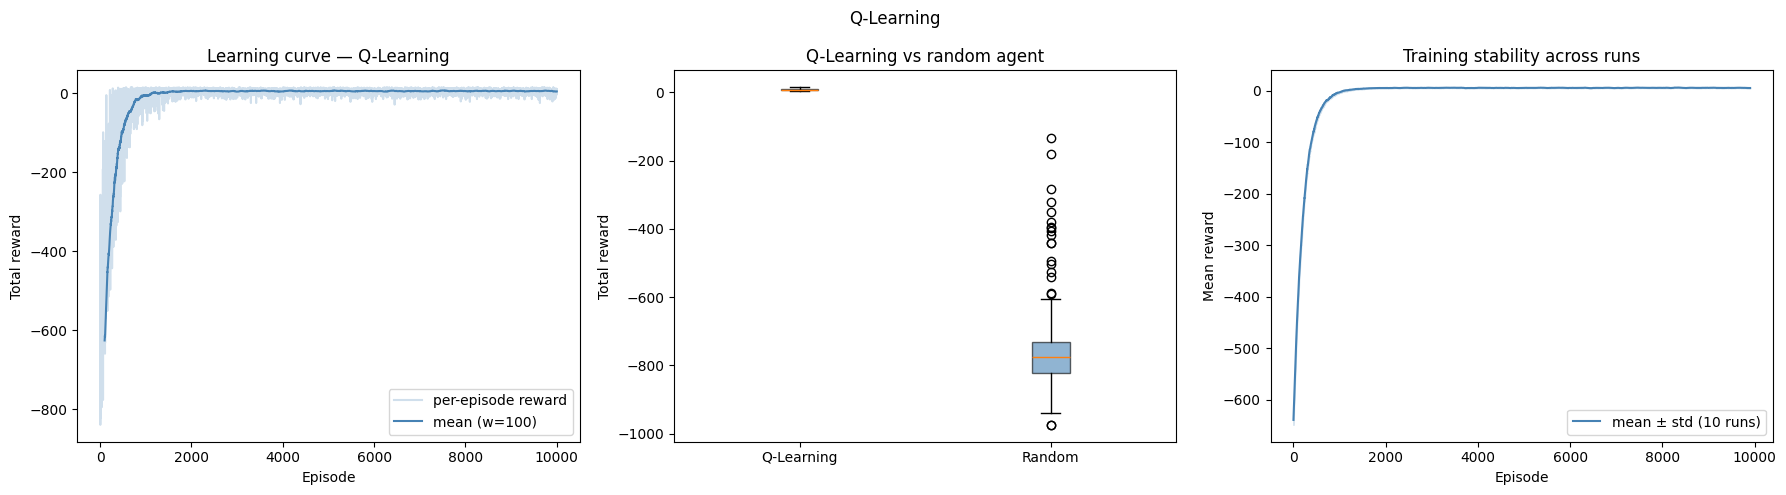

In [12]:
experiment = Experiment("Taxi-v4", config=TrainingConfig(), n_runs=10)
experiment.run(eval_episodes=500)
experiment.print_summary()
experiment.plot_all()

We can notice that the implemented algorithm handled the problem MUCH better than the agent performing random actions. This means the Q-Learning algorithm has been implemented correctly. Both the learning curve and training stability show exactly what we had expected - a steadily improving agent until a given point.

Now the `grid_search` will be run to help us find the most optimal parameters for the algorithm. It runs multiple experiments and sums their results up in a comprehensive table.

Grid search: 100%|██████████| 128/128 [17:08<00:00,  8.04s/it]


Algorithm: Q-Learning
Stability (1 runs):  mean=-12.36  std=0.00  min=-12.36  max=-12.36
Q-Learning eval:     8.20
Random agent:     -764.73


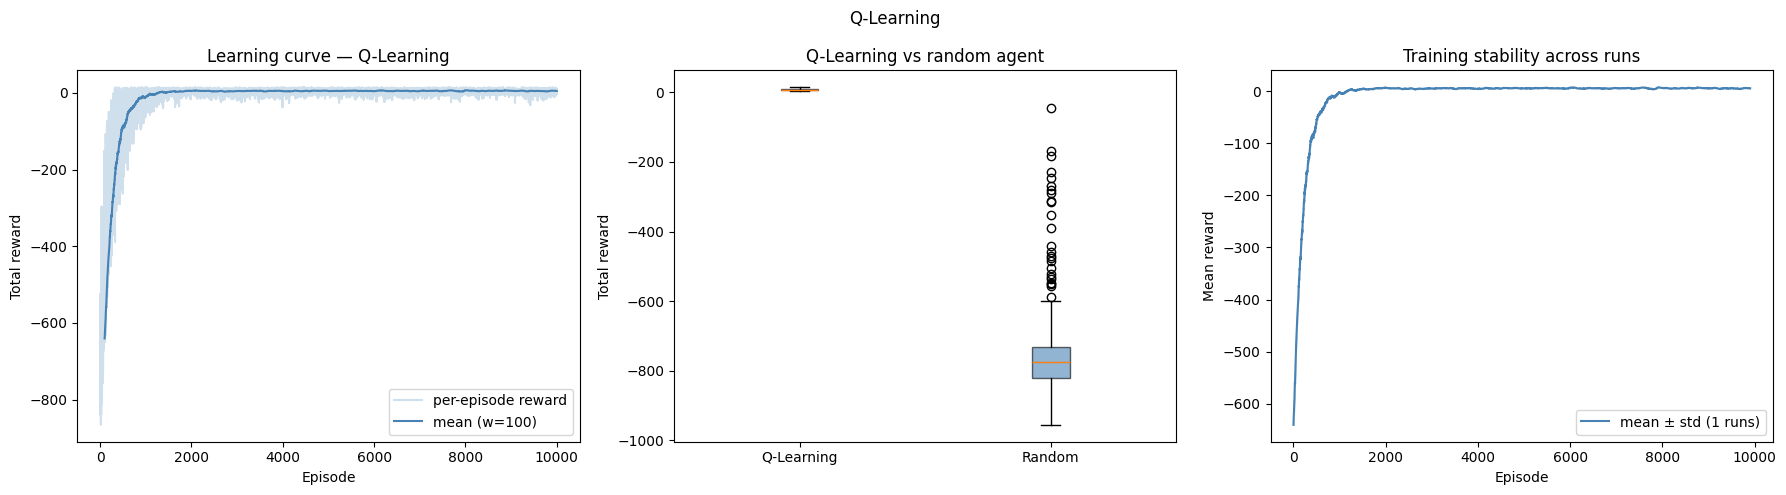

,alpha,gamma,epsilon_decay,epsilon_end,eval_mean,eval_std,eval_min,eval_max,train_mean
0,0.1,0.950,0.9950,0.05,8.20,2.54,3.0,15.0,-12.36
1,0.8,0.990,0.9995,0.01,8.18,2.65,3.0,15.0,-35.55
2,0.1,0.990,0.9900,0.01,8.17,2.66,3.0,15.0,-6.07
3,0.1,0.970,0.9950,0.01,8.13,2.60,3.0,15.0,-10.51
4,0.3,0.999,0.9990,0.01,8.13,2.65,3.0,15.0,-19.23
5,0.3,0.970,0.9995,0.05,8.13,2.54,3.0,14.0,-38.86
6,0.5,0.999,0.9990,0.05,8.11,2.69,2.0,15.0,-18.42
7,0.1,0.999,0.9900,0.01,8.11,2.63,3.0,15.0,-5.89
8,0.1,0.950,0.9950,0.01,8.10,2.60,3.0,15.0,-10.41
9,0.8,0.970,0.9990,0.01,8.10,2.71,3.0,15.0,-15.81


In [3]:
results = grid_search(
    env_id="Taxi-v4",
    param_grid={
        "alpha": [0.1, 0.3, 0.5, 0.8],
        "gamma": [0.95, 0.97, 0.99, 0.999],
        "epsilon_decay": [0.990, 0.995, 0.999, 0.9995],
        "epsilon_end": [0.01, 0.05],
    },
    save_path="grid_search.csv",
    use_sarsa=False
);

The `grid_search` has found a better parameter configuration than our arbitrary one. This is a good sign.

Now, a single experiment will be run on 10 runs, using the parameters found by the `grid_search`. We will see if the results are better than for the arbitrary values.

100%|██████████| 1/1 [00:08<00:00,  8.46s/it]


Algorithm: Q-Learning
Stability (1 runs):  mean=-12.17  std=0.00  min=-12.17  max=-12.17
Q-Learning eval:     8.10
Random agent:     -776.42


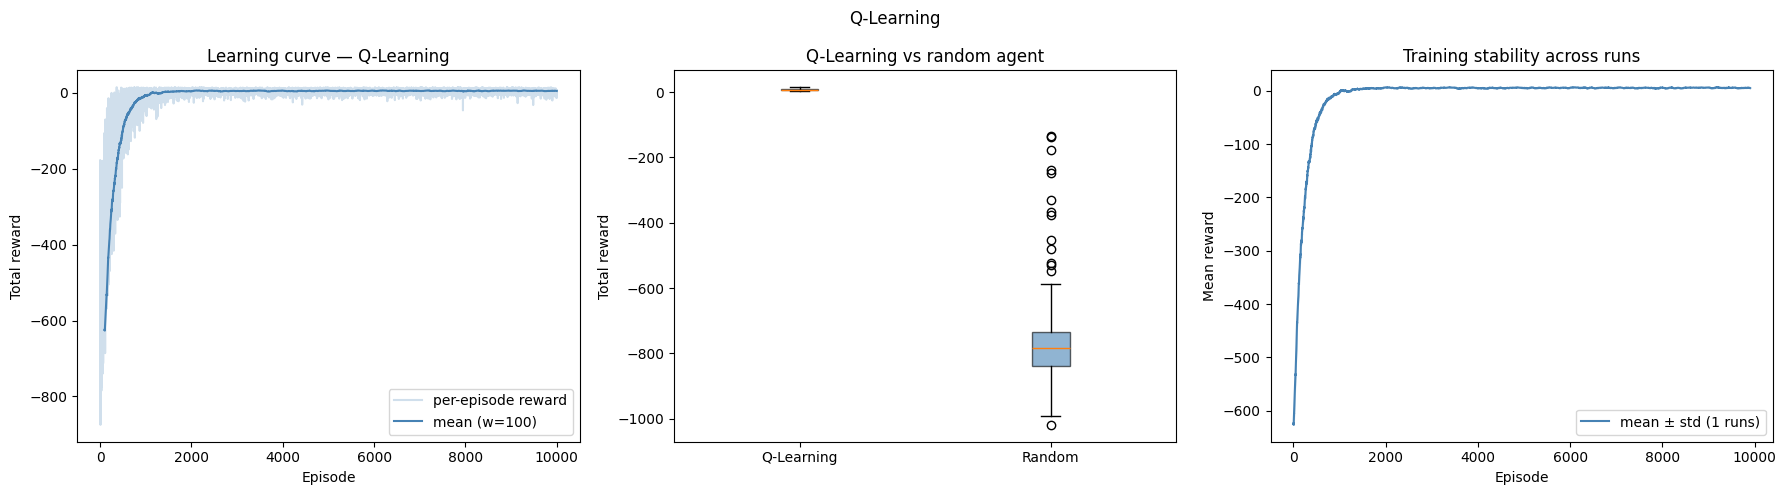

In [19]:
config = TrainingConfig(
    alpha=0.1,
    gamma=0.950,
    epsilon_decay=0.9950,
    epsilon_end=0.05
)
experiment = Experiment("Taxi-v4", config=config, n_runs=1)
experiment.run(eval_episodes=500)
experiment.print_summary()
experiment.plot_all()

This proves that our `grid_search` found actually better parameters than the arbitrary ones.

### SARSA

Now, the same experiments will be ran using the `SARSA` algorithm to compare it to the results of `Q-Learning`

100%|██████████| 10/10 [01:06<00:00,  6.67s/it]


Algorithm: SARSA
Stability (10 runs):  mean=-12.86  std=0.50  min=-13.64  max=-12.12
SARSA eval:     7.86
Random agent:     -767.76


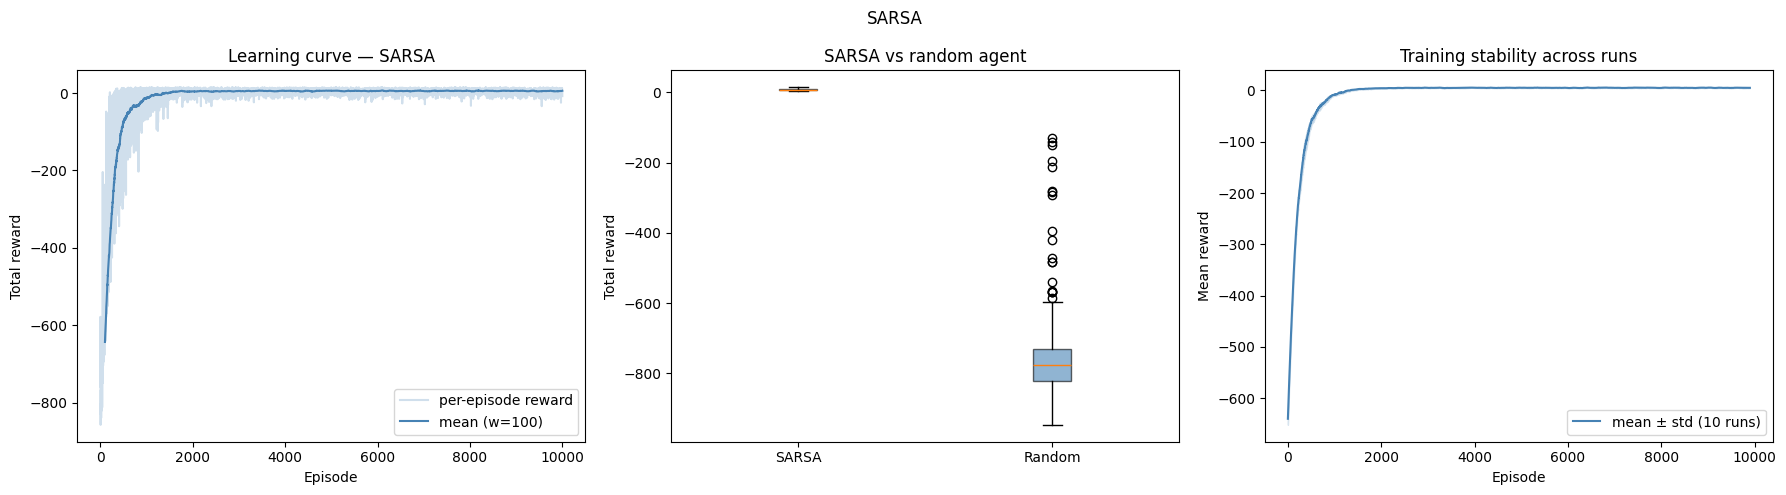

In [7]:
experiment = Experiment("Taxi-v4", config=TrainingConfig(), n_runs=10, use_sarsa=True)
experiment.run(eval_episodes=500)
experiment.print_summary()
experiment.plot_all()

The first experiment was slightly worse than `Q-Learning`. This is to be expected. `SARSA` performs better in environments, where making a mistake is very bad (like walking along a cliff), but our `Taxi-v4` is not exactly like this.

The `grid_search` will be ran again, this time using the `SARSA` algorithm. Maybe it can find a solution actually better than the best `Q-Learning`.

Grid search: 100%|██████████| 128/128 [17:24<00:00,  8.16s/it]


Algorithm: SARSA
Stability (1 runs):  mean=-67.39  std=0.00  min=-67.39  max=-67.39
SARSA eval:     8.14
Random agent:     -766.63


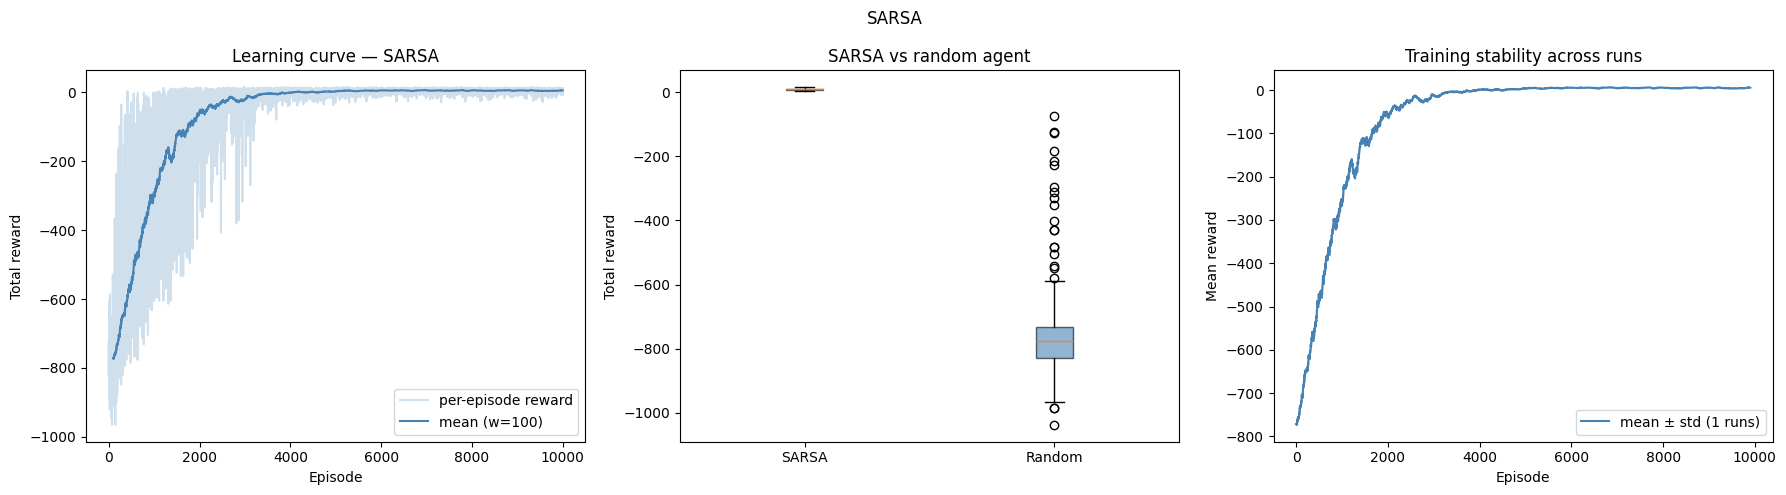

,alpha,gamma,epsilon_decay,epsilon_end,eval_mean,eval_std,eval_min,eval_max,train_mean
0,0.1,0.999,0.9995,0.05,8.14,2.74,2.0,15.0,-67.39
1,0.1,0.950,0.9900,0.05,8.10,2.65,3.0,15.0,-8.48
2,0.1,0.970,0.9950,0.01,8.09,2.52,3.0,15.0,-9.93
3,0.1,0.990,0.9950,0.01,8.07,2.40,3.0,14.0,-10.15
4,0.1,0.999,0.9900,0.01,8.06,2.51,3.0,15.0,-5.68
5,0.1,0.990,0.9995,0.05,8.04,2.69,2.0,15.0,-68.45
6,0.1,0.970,0.9950,0.05,7.99,2.52,3.0,15.0,-12.68
7,0.1,0.950,0.9950,0.05,7.98,2.63,3.0,15.0,-12.69
8,0.1,0.999,0.9950,0.01,7.98,2.49,3.0,15.0,-10.26
9,0.1,0.970,0.9995,0.05,7.97,2.68,3.0,15.0,-72.06


In [4]:
results = grid_search(
    env_id="Taxi-v4",
    param_grid={
        "alpha": [0.1, 0.3, 0.5, 0.8],
        "gamma": [0.95, 0.97, 0.99, 0.999],
        "epsilon_decay": [0.990, 0.995, 0.999, 0.9995],
        "epsilon_end": [0.01, 0.05],
    },
    save_path="grid_search_sarsa.csv",
    use_sarsa=True
);

Again, let's test the found params alone, as a part of a single experiment.

100%|██████████| 1/1 [00:10<00:00, 10.35s/it]


Algorithm: SARSA
Stability (1 runs):  mean=-69.92  std=0.00  min=-69.92  max=-69.92
SARSA eval:     8.05
Random agent:     -776.74


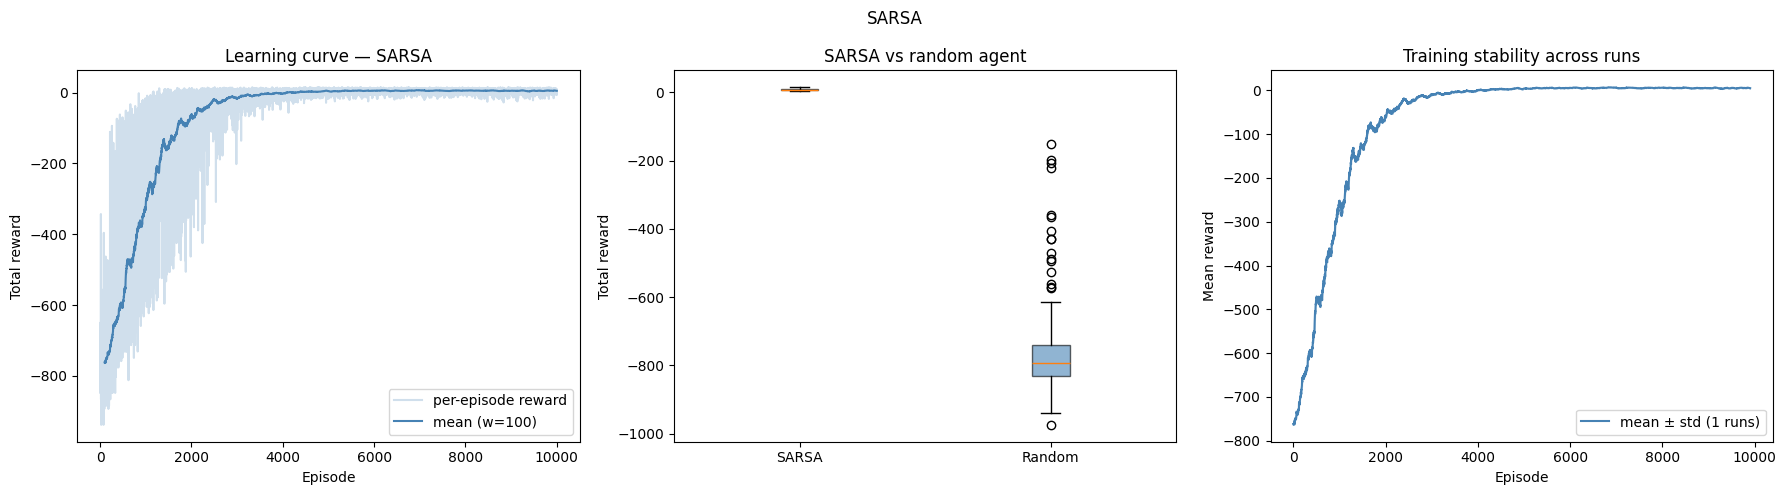

In [3]:
config = TrainingConfig(
    alpha=0.1,
    gamma=0.999,
    epsilon_decay=0.9995,
    epsilon_end=0.05
)
experiment = Experiment("Taxi-v4", config=config, n_runs=1, use_sarsa=True)
experiment.run(eval_episodes=500)
experiment.print_summary()
experiment.plot_all()

Once again, the `grid_search` found a better solution than before. Still, it was a bit worse than the default `Q-Learning`

## Summary

The `Q-Leaning` and `SARSA` algorithms have been implemented correctly. The trained agents perform much better than the random ones. Both algorithms yield similar results, however `Q-Learning` did return slightly higher evaluations than `SARSA`.